# 01 · 데이터 로드 / ChromaDB 인덱싱 / 검색 품질 비교

**실험 매트릭스**: 청킹 전략 3종 × 임베딩 모델 2종 = **6개 조합**

| 청킹 | 설명 | 임베딩 | 차원 |
|---|---|---|---|
| `fixed` | 고정 500자 (overlap 50) | `small` | 1536 |
| `sentence` | 문장 경계 유지, 최대 600자 | `large` | 3072 |
| `semantic` | 임베딩 유사도 기반 분할 | | |

**RDB**: SQLite (로컬 테스트) / MySQL (운영) 양쪽 지원

## 0. 패키지 설치 (최초 1회)

In [1]:
# !pip install openai chromadb sqlalchemy pymysql numpy pandas matplotlib seaborn tqdm -q

## 1. 임포트 & 초기화

In [2]:
import sys, json, re
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI

from config import (
    OPENAI_API_KEY, EMBEDDING_MODELS, CHUNKING_STRATEGIES,
    EXPERIMENT_COMBOS, article_collection_name,
    DB_URL, DATA_DIR, EVAL_QUERIES,
)
from db.rdb import get_engine, init_tables, load_articles, upsert_article
from db.vectordb import (
    get_chroma_client, build_article_collection,
    build_policy_collection, build_bill_collection,
    evaluate_retrieval, retrieve_from_articles, retrieve_for_debate,
)
from config import (
    PREPROCESSED_NEWS_DIR, PREPROCESSED_POLICY_FILE,
    PREPROCESSED_POLICY_META, PREPROCESSED_BILL_DIR, PREPROCESSED_BILL_META,
    policy_collection_name, bill_collection_name,
)

# ── 클라이언트 ────────────────────────────────────────────────────
client = OpenAI(api_key=OPENAI_API_KEY)   # 또는 "sk-..."
engine = get_engine(DB_URL)               # SQLite 기본
chroma = get_chroma_client()

init_tables(engine)
print("초기화 완료")
print(f"  DB URL  : {DB_URL}")
print(f"  Chroma  : {chroma}")


DB 테이블 초기화 완료
초기화 완료
  DB URL  : sqlite:///./politalk_dev.db
  Chroma  : <chromadb.api.client.Client object at 0x10dbbe9e0>


## 2. 뉴스 크롤러 출력 → RDB 저장

> `news_crawler/output/*.jsonl` 파일을 읽어 `articles` 테이블에 upsert

In [3]:
def load_jsonl_articles(date_str: str = "news_20260522") -> list[dict]:
    jsonl = DATA_DIR / f"{date_str}.jsonl"
    arts = []
    with open(jsonl, encoding="utf-8") as f:
        for line in f:
            try:
                arts.append(json.loads(line))
            except:
                continue
    return arts

def load_content(article: dict) -> str:
    path = DATA_DIR / article.get("file_path", "")
    if not path.exists():
        return ""
    raw = path.read_text(encoding="utf-8", errors="ignore")
    return re.sub(r"\s+", " ", re.sub(r"<[^>]+>", "", raw)).strip()

# JSONL 로드
raw_articles = load_jsonl_articles("news_20260522")
print(f"JSONL 기사 수: {len(raw_articles)}")

# 본문 로드 + RDB upsert
saved = 0
for art in tqdm(raw_articles[:100], desc="RDB 저장"):
    art["content"] = load_content(art)
    if len(art.get("content", "")) > 80:
        art_id = upsert_article(engine, art)
        art["id"] = art_id
        saved += 1

print(f"RDB 저장 완료: {saved}건")

# RDB에서 다시 로드
db_articles = load_articles(engine, limit=100)
print(f"DB 기사 수: {len(db_articles)}")


JSONL 기사 수: 1459


RDB 저장: 100%|██████████| 100/100 [00:00<00:00, 16226.18it/s]

RDB 저장 완료: 0건
DB 기사 수: 40


## 2-b. 1차 전처리 데이터 로드 (뉴스 / 정책 / 법안)

`pipeline/1차 전처리/` 폴더의 CSV 메타데이터 + MD 본문 파일을 읽어
파이프라인 형식(`{data_id, content, source_url, ...}`)으로 변환합니다.

| 카테고리 | 파일 구조 | 개수 |
|---|---|---|
| 뉴스 | `news_md/*.md` + `news_metadata_youth.csv` | 40개 |
| 정책 | 단일 `youth_policies_document.md` (POLICY_START/END) + CSV | 1,685개 |
| 법안 | `bill_md/*.md` + `metadata_youth_only.csv` | 1,614개 |


In [4]:
import csv, re as _re

# ── 뉴스 로더 ─────────────────────────────────────────────────────────────
def load_preprocessed_news() -> list[dict]:
    md_dir = PREPROCESSED_NEWS_DIR / "news_md"
    arts   = []
    with open(PREPROCESSED_NEWS_DIR / "news_metadata_youth.csv", encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            md_file = md_dir / f"{row['data_id']}.md"
            content = md_file.read_text(encoding="utf-8", errors="ignore") if md_file.exists() else ""
            arts.append({
                "data_id":        row["data_id"],
                "data_title":     row["data_title"],
                "title":          row["data_title"],
                "content":        content.strip(),
                "url":            row["source_url"],
                "source_url":     row["source_url"],
                "press":          row.get("press", ""),
                "publisher":      row.get("press", ""),
                "published_at":   row.get("published_at", ""),
                "is_youth_related": row.get("is_youth_related", "1"),
            })
    return arts

# ── 정책 로더 ─────────────────────────────────────────────────────────────
def load_preprocessed_policies() -> list[dict]:
    raw    = PREPROCESSED_POLICY_FILE.read_text(encoding="utf-8", errors="ignore")
    chunks = _re.split(r"---POLICY_START---", raw)[1:]
    bodies = [c.split("---POLICY_END---")[0].strip() for c in chunks]
    pols   = []
    with open(PREPROCESSED_POLICY_META, encoding="utf-8-sig") as f:
        rows = list(csv.DictReader(f))
    for i, row in enumerate(rows):
        raw_id = str(row.get("data_id", "")).strip()
        try:    data_id = str(int(float(raw_id)))   # 과학표기법 방지
        except: data_id = raw_id
        pols.append({
            "data_id":    data_id,
            "data_title": row.get("data_title", ""),
            "content":    bodies[i] if i < len(bodies) else "",
            "source_url": row.get("source_url", ""),
            "department": row.get("department", ""),
            "category_id":row.get("category_id", ""),
        })
    return pols

# ── 법안 로더 ─────────────────────────────────────────────────────────────
def load_preprocessed_bills() -> list[dict]:
    md_dir = PREPROCESSED_BILL_DIR / "bill_md"
    bills  = []
    with open(PREPROCESSED_BILL_META, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            md_file = md_dir / f"{row['data_id']}.md"
            content = md_file.read_text(encoding="utf-8", errors="ignore") if md_file.exists() else ""
            bills.append({
                "data_id":    row["data_id"],
                "data_title": row.get("data_title", ""),
                "content":    content.strip(),
                "source_url": row.get("source_url", ""),
                "department": row.get("department", ""),
                "bill_num":   row.get("bill_num", ""),
                "proposer":   row.get("proposer", ""),
            })
    return bills

# ── 로드 실행 ─────────────────────────────────────────────────────────────
news_data   = load_preprocessed_news()
policy_data = load_preprocessed_policies()
bill_data   = load_preprocessed_bills()

print(f"뉴스:  {len(news_data):>5}개  | 본문 있는 것: {sum(1 for d in news_data if d['content'])}")
print(f"정책: {len(policy_data):>5}개  | 본문 있는 것: {sum(1 for d in policy_data if d['content'])}")
print(f"법안: {len(bill_data):>5}개  | 본문 있는 것: {sum(1 for d in bill_data if d['content'])}")

print("\n--- 뉴스 샘플 ---")
print(news_data[0]["data_title"], "|", news_data[0]["content"][:80])
print("\n--- 정책 샘플 ---")
print(policy_data[0]["data_title"], "|", policy_data[0]["content"][:80])
print("\n--- 법안 샘플 ---")
print(bill_data[0]["data_title"], "|", bill_data[0]["content"][:80])


뉴스:     40개  | 본문 있는 것: 40
정책:  1685개  | 본문 있는 것: 1685
법안:  1614개  | 본문 있는 것: 1614

--- 뉴스 샘플 ---
서귀포시, 산사태 현장 예방단 기간제근로자 채용 공고 | 서귀포시는 산림청 직접 일자리 사업인 2026년 산사태 현장 예방단 기간제근로자를 8일부터 오는 15일까지 공개모집한다고 밝혔다.

선발 규모는

--- 정책 샘플 ---
주택금융공사 월세자금보증 | 서비스ID: 116010000001
정책명: 주택금융공사 월세자금보증
서비스분야: 주거·자립
지원유형: 기타, 상담/법률지원
소관기관: 한국주택

--- 법안 샘플 ---
대중문화예술산업발전법 일부개정법률안 | # 대중문화예술산업발전법 일부개정법률안

## 법안 기본 내용

| 항목 | 내용 |
|---|---|
| 의안번호 | 2200033 |
| 법


### 2-c. 1차 전처리 뉴스 → RDB upsert

In [5]:
# 1차 전처리 뉴스를 articles 테이블에 저장 (db_articles 재정의)
saved = 0
for art in tqdm(news_data, desc="RDB 저장 (1차 전처리 뉴스)"):
    if len(art.get("content", "")) > 50:
        art["id"] = upsert_article(engine, art)
        saved += 1

db_articles = news_data  # 이후 셀에서 참조
print(f"RDB 저장 완료: {saved}건")


RDB 저장 (1차 전처리 뉴스): 100%|██████████| 40/40 [00:00<00:00, 842.40it/s]

RDB 저장 완료: 40건


## 3. 청킹 전략 3종 시연

In [6]:
from utils import chunk_fixed, chunk_by_sentence, chunk_semantic

sample = db_articles[0]
text   = sample["content"]
print(f"원문 길이: {len(text)}자  |  제목: {sample['title'][:50]}\n")

fixed_chunks  = chunk_fixed(text)
sent_chunks   = chunk_by_sentence(text)
sem_chunks    = chunk_semantic(text, client)  # API 호출

for name, chunks in [("fixed", fixed_chunks), ("sentence", sent_chunks), ("semantic", sem_chunks)]:
    print(f"[{name}] {len(chunks)}개 청크  |  첫 청크: {chunks[0][:80]}...")


원문 길이: 497자  |  제목: 서귀포시, 산사태 현장 예방단 기간제근로자 채용 공고

[fixed] 1개 청크  |  첫 청크: 서귀포시는 산림청 직접 일자리 사업인 2026년 산사태 현장 예방단 기간제근로자를 8일부터 오는 15일까지 공개모집한다고 밝혔다.

선발 규모는...
[sentence] 1개 청크  |  첫 청크: 서귀포시는 산림청 직접 일자리 사업인 2026년 산사태 현장 예방단 기간제근로자를 8일부터 오는 15일까지 공개모집한다고 밝혔다. 선발 규모는 ...
[semantic] 3개 청크  |  첫 청크: 서귀포시는 산림청 직접 일자리 사업인 2026년 산사태 현장 예방단 기간제근로자를 8일부터 오는 15일까지 공개모집한다고 밝혔다. 선발 규모는 ...


/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_47856/2710301327.py:16: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_47856/2710301327.py:16: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_47856/2710301327.py:16: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_47856/2710301327.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_47856/2710301327.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/i

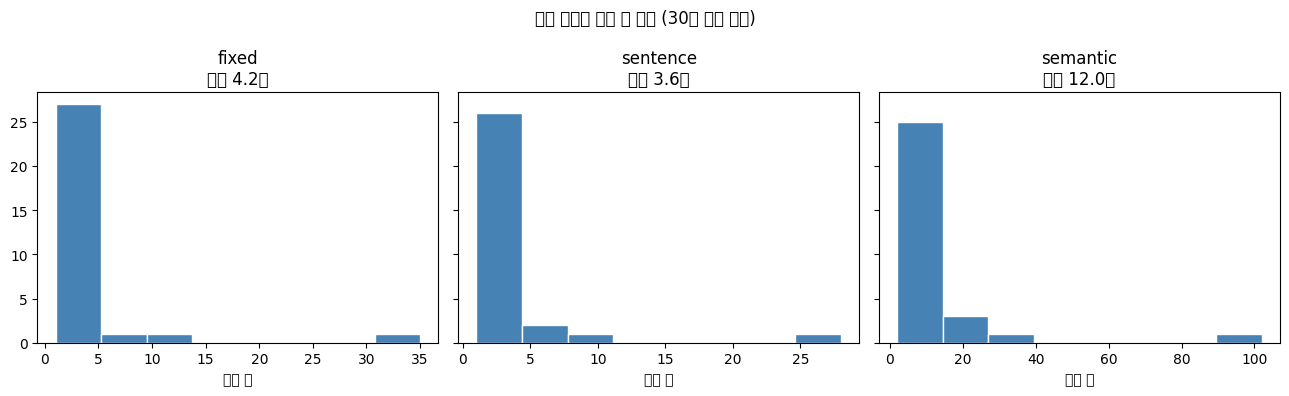

In [7]:
# 30개 기사 청크 수 분포 시각화
sample30 = [a["content"] for a in db_articles[:30]]

stats = {
    "fixed":    [len(chunk_fixed(t))            for t in sample30],
    "sentence": [len(chunk_by_sentence(t))      for t in sample30],
    "semantic": [len(chunk_semantic(t, client)) for t in sample30],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (name, counts) in zip(axes, stats.items()):
    ax.hist(counts, bins=8, color="steelblue", edgecolor="white")
    ax.set_title(f"{name}\n평균 {np.mean(counts):.1f}개")
    ax.set_xlabel("청크 수")
plt.suptitle("청킹 전략별 청크 수 분포 (30개 기사 샘플)")
plt.tight_layout()
plt.show()


## 4. 6개 ChromaDB 컬렉션 빌드

> ⚠️ API 비용 발생. `SAMPLE_SIZE = 20` 으로 먼저 테스트하세요.

In [8]:
SAMPLE_SIZE = 20   # 전체 실행: len(db_articles)
sample_arts = db_articles[:SAMPLE_SIZE]

for strategy, model_key in EXPERIMENT_COMBOS:
    col_name = article_collection_name(strategy, model_key)
    print(f"\n[{col_name}] 빌드 중...")
    build_article_collection(
        chroma, client,
        articles=sample_arts,
        strategy=strategy,
        model_key=model_key,
        reset=True,
    )

print("\n모든 컬렉션 빌드 완료!")



[articles_fixed_small] 빌드 중...


[articles_fixed_small] 인덱싱: 100%|██████████| 2/2 [00:00<00:00,  2.18it/s]


  ✓ articles_fixed_small: +67 청크 (총 67)

[articles_fixed_large] 빌드 중...


[articles_fixed_large] 인덱싱: 100%|██████████| 2/2 [00:00<00:00,  2.60it/s]


  ✓ articles_fixed_large: +67 청크 (총 67)

[articles_sentence_small] 빌드 중...


...

  ✓ articles_sentence_large: +58 청크 (총 58)

[articles_semantic_small] 빌드 중...


[articles_semantic_small] 인덱싱: 100%|██████████| 4/4 [00:01<00:00,  2.01it/s]


  ✓ articles_semantic_small: +196 청크 (총 196)

[articles_semantic_large] 빌드 중...


[articles_semantic_large] 인덱싱: 100%|██████████| 4/4 [00:01<00:00,  2.54it/s]

  ✓ articles_semantic_large: +196 청크 (총 196)

모든 컬렉션 빌드 완료!


## 4-b. 정책/법안 ChromaDB 컬렉션 빌드

토론 RAG에서 기사 + 정책 + 법안 통합 검색을 위해 별도 컬렉션을 빌드합니다.
청킹 전략은 `sentence` 고정 (6조합 실험 대상 아님).

In [9]:
# DEBATE_SAMPLE_SIZE: 인덱싱할 정책/법안 수 (None이면 전체)
# 전체 실행 시 비용이 크므로 처음에는 소량으로 테스트하세요.
DEBATE_SAMPLE_SIZE = 200   # 전체: None

try:
    MODEL_KEY_FOR_DEBATE = BEST_MODEL
except NameError:
    MODEL_KEY_FOR_DEBATE = "large"

policy_sample = [p for p in policy_data if p["content"]]
bill_sample   = [b for b in bill_data   if b["content"]]
if DEBATE_SAMPLE_SIZE:
    policy_sample = policy_sample[:DEBATE_SAMPLE_SIZE]
    bill_sample   = bill_sample[:DEBATE_SAMPLE_SIZE]

print(f"인덱싱 대상: 정책 {len(policy_sample)}개 / 법안 {len(bill_sample)}개  (모델: {MODEL_KEY_FOR_DEBATE})")

# 정책 컬렉션 빌드
print("\n정책 컬렉션 빌드 중...")
build_policy_collection(
    chroma, client,
    policies=policy_sample,
    model_key=MODEL_KEY_FOR_DEBATE,
    reset=True,
)

# 법안 컬렉션 빌드
print("\n법안 컬렉션 빌드 중...")
build_bill_collection(
    chroma, client,
    bills=bill_sample,
    model_key=MODEL_KEY_FOR_DEBATE,
    reset=True,
)

print("\n✓ 정책/법안 컬렉션 빌드 완료")
print(f"  정책 컬렉션: {policy_collection_name(MODEL_KEY_FOR_DEBATE)}")
print(f"  법안 컬렉션: {bill_collection_name(MODEL_KEY_FOR_DEBATE)}")

인덱싱 대상: 정책 200개 / 법안 200개  (모델: large)

정책 컬렉션 빌드 중...


[policies_large] 인덱싱: 100%|██████████| 2/2 [00:00<00:00,  2.20it/s]


  ✓ policies_large: +88 청크 (총 88)

법안 컬렉션 빌드 중...


[bills_large] 인덱싱: 100%|██████████| 32/32 [00:23<00:00,  1.36it/s]

  ✓ bills_large: +1595 청크 (총 1595)

✓ 정책/법안 컬렉션 빌드 완료
  정책 컬렉션: policies_large
  법안 컬렉션: bills_large


### 4-c. 토론 통합 검색 확인

In [10]:
test_query = "청년 월세 지원 주거 정책"
debate_results = retrieve_for_debate(
    test_query, chroma,
    model_key=MODEL_KEY_FOR_DEBATE,
    openai_client=client,
    strategy=BEST_STRATEGY if "BEST_STRATEGY" in dir() else "sentence",
    top_k=6,
)

print(f"쿼리: '{test_query}'\n")
for i, r in enumerate(debate_results):
    doc_type = r["metadata"].get("doc_type", "?")
    title    = r["metadata"].get("title", r["metadata"].get("data_title", ""))[:50]
    url      = r["metadata"].get("source_url", r["metadata"].get("url", ""))
    print(f"[{i+1}] [{doc_type.upper()}] score={r['score']:.4f}")
    print(f"  제목: {title}")
    print(f"  내용: {r['content'][:100]}...")
    print(f"  출처: {url or '없음'}")
    print()


쿼리: '청년 월세 지원 주거 정책'

[1] [POLICY] score=0.2030
  제목: 소년원 출원생 등 소외계층 청소년을 위한 청소년자립생활관 운영 지원
  내용: 서비스ID: 127000000037
정책명: 소년원 출원생 등 소외계층 청소년을 위한 청소년자립생활관 운영 지원
서비스분야: 보육·교육
지원유형: 서비스(일자리)
소관기관: 법무부...
  출처: https://www.gov.kr/portal/rcvfvrSvc/dtlEx/127000000037

[2] [POLICY] score=0.1646
  제목: 청년 창업인의 집 운영
  내용: 서비스ID: 311000000131
정책명: 청년 창업인의 집 운영
서비스분야: 고용·창업
지원유형: 시설이용
소관기관: 서울특별시 은평구
부서명: 청장년희망과
상세조회URL: h...
  출처: https://www.gov.kr/portal/rcvfvrSvc/dtlEx/311000000131

[3] [POLICY] score=0.1022
  제목: 아동복지시설 만기퇴소 청소년 자립정착금 지원
  내용: 서비스ID: 310000000101
정책명: 아동복지시설 만기퇴소 청소년 자립정착금 지원
서비스분야: 주거·자립
지원유형: 현금
소관기관: 서울특별시 노원구
부서명: 아동청소년과
...
  출처: https://www.gov.kr/portal/rcvfvrSvc/dtlEx/310000000101

[4] [ARTICLE] score=0.0000
  제목: 부여군, 전입 학생 생활지원 확대… 중·고생·대학생 생활용품비 지원
  내용: 이번 사업은 관외 지역에서 부여군으로 주소를 이전한 학생들에게 생활용품 구입비를 지원하는 제도로, 중·고등학생과 대학(원)생, 대학 신입생 등을 대상으로 차등 지원된다. 중·고등학...
  출처: https://www.joongdo.co.kr/web/view.php?key=20260519010004938

[5] [ARTICLE] score=0.0000
  제목: 부여군, 전입 

## 5. 검색 품질 평가 (Top-1 유사도 비교)

In [11]:
eval_results: dict[str, dict] = {}

for strategy, model_key in tqdm(EXPERIMENT_COMBOS, desc="검색 평가"):
    col_name   = article_collection_name(strategy, model_key)
    model_name = EMBEDDING_MODELS[model_key]
    try:
        col = chroma.get_collection(col_name)
    except Exception:
        print(f"  [{col_name}] 컬렉션 없음 — 4번 셀을 먼저 실행하세요")
        continue

    result = evaluate_retrieval(EVAL_QUERIES, col, model_name, client, top_k=1)
    eval_results[col_name] = result
    print(f"  {col_name}: avg={result['avg_score']:.4f}")


검색 평가:  17%|█▋        | 1/6 [00:01<00:06,  1.22s/it]

  articles_fixed_small: avg=0.0046


검색 평가:  33%|███▎      | 2/6 [00:02<00:04,  1.17s/it]

  articles_fixed_large: avg=0.0143


검색 평가:  50%|█████     | 3/6 [00:03<00:03,  1.14s/it]

...

  articles_sentence_large: avg=0.0136


검색 평가:  83%|████████▎ | 5/6 [00:06<00:01,  1.41s/it]

  articles_semantic_small: avg=0.0534


검색 평가: 100%|██████████| 6/6 [00:07<00:00,  1.28s/it]

  articles_semantic_large: avg=0.0562


/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/dacare/lib/python3.10/site-packages/seaborn/utils.py:61: UserW

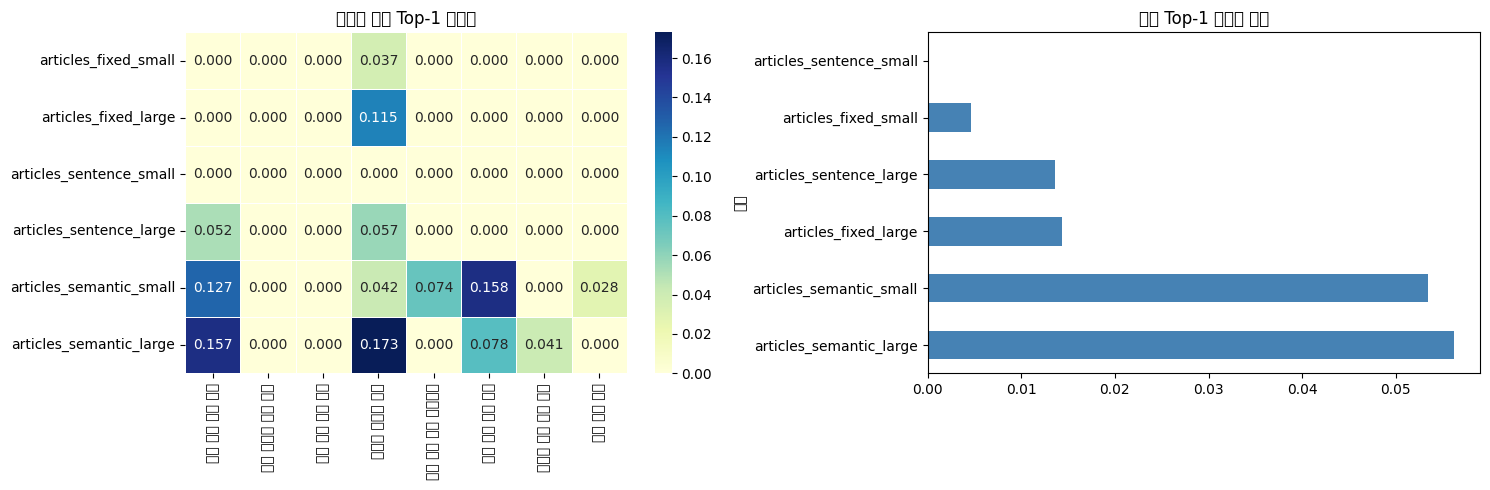


=== 검색 품질 순위 ===


,조합,평균_Top1_유사도
0,articles_semantic_large,0.056188
1,articles_semantic_small,0.053407
2,articles_fixed_large,0.014321
3,articles_sentence_large,0.013563
4,articles_fixed_small,0.004613
5,articles_sentence_small,0.000000



최고 성능: articles_semantic_large  (strategy=semantic, model=large)


14

In [12]:
# 결과 데이터프레임 + 시각화
df_score = pd.DataFrame(
    {k: v["scores"] for k, v in eval_results.items()},
    index=EVAL_QUERIES,
)

df_summary = (
    pd.DataFrame({"조합": list(eval_results.keys()),
                  "평균_Top1_유사도": [v["avg_score"] for v in eval_results.values()]})
    .sort_values("평균_Top1_유사도", ascending=False)
    .reset_index(drop=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(df_score.T, annot=True, fmt=".3f", cmap="YlGnBu",
            ax=ax1, linewidths=0.5)
ax1.set_title("조합별 쿼리 Top-1 유사도")

df_summary.plot.barh(x="조합", y="평균_Top1_유사도", ax=ax2,
                     color="steelblue", legend=False)
ax2.set_title("평균 Top-1 유사도 순위")
plt.tight_layout()
plt.show()

print("\n=== 검색 품질 순위 ===")
display(df_summary)

BEST_COMBO = df_summary.iloc[0]["조합"]  # e.g. "articles_sentence_large"
# strategy/model_key 파싱 (articles_ 제거)
parts = BEST_COMBO.replace("articles_", "").rsplit("_", 1)
BEST_STRATEGY, BEST_MODEL = parts[0], parts[1]
print(f"\n최고 성능: {BEST_COMBO}  (strategy={BEST_STRATEGY}, model={BEST_MODEL})")

Path("./output/best_combo.txt").write_text(f"{BEST_STRATEGY}_{BEST_MODEL}")


## 6. 검색 예시 확인

In [13]:
query = "청년 주거 지원 월세 보조"
results = retrieve_from_articles(query, chroma, BEST_STRATEGY, BEST_MODEL, client, top_k=3)

print(f"쿼리: '{query}'\n")
for i, r in enumerate(results):
    meta = r["metadata"]
    print(f"[{i+1}] score={r['score']:.4f}")
    print(f"  제목: {meta.get('title','')[:60]}")
    print(f"  출처: {meta.get('publisher', meta.get('press','?'))}")
    print(f"  내용: {r['content'][:120]}...\n")


쿼리: '청년 주거 지원 월세 보조'

[1] score=0.0437
  제목: 익산시, 2026년 예산 1조8686억 편성
  출처: ?
  내용: 청년 지원과 교육 혁신 등 미래 세대를 위한 준비도 놓치지 않았다. 청년 정책 사업으로 익산형 청년근로수당 36억 원 청년·신혼부부 주택구입 대출이자 36억 원 청년농업인 영농정착금 26억 원 청년월세지원 22억 원...

[2] score=0.0177
  제목: 익산시, 내년 예산 1조 8,686억 편성...성장 동력 강화와 민생 안정위한...
  출처: ?
  내용: 청년 정책 사업으로 익산형 청년근로수당 36억 원 청년·신혼부부 주택구입 대출이자 36억 원 청년농업인 영농정착금 26억 원 청년월세지원 22억 원 전세 보증금 이자지원 14억 원 공공임대주택 임대보증금 7억 원 등...

[3] score=0.0153
  제목: 익산시, 내년 예산 1조 8,686억…'민생·성장 집중'
  출처: ?
  내용: 청년 지원과 교육 혁신 등 미래 세대를 위한 준비도 놓치지 않았다. 청년 정책 사업으로 익산형 청년근로수당 36억원 청년·신혼부부 주택구입 대출이자 36억원 청년농업인 영농정착금 26억원 청년월세지원 22억원 전세 ...

